In [ ]:
import kagglehub
# Download latest version
path = kagglehub.dataset_download("camnugent/california-housing-prices")
print("Path to dataset files:",path)

Using Colab cache for faster access to the 'california-housing-prices' dataset.
Path to dataset files: /kaggle/input/california-housing-prices


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
file_path = "/kaggle/input/california-housing-prices/housing.csv"
df = pd.read_csv(file_path)

X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (16512, 9)
Test set shape: (4128, 9)


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

baseline_model = LinearRegression()
baseline_model.fit(X_train_imputed, y_train)

y_train_pred = baseline_model.predict(X_train_imputed)
y_test_pred = baseline_model.predict(X_test_imputed)

train_mse_baseline = mean_squared_error(y_train, y_train_pred)
test_mse_baseline = mean_squared_error(y_test, y_test_pred)

print("\nBaseline Linear Regression")
print("Training MSE:", train_mse_baseline)
print("Test MSE:", test_mse_baseline)


Baseline Linear Regression
Training MSE: 4683203783.504253
Test MSE: 4904409297.414918


In [ ]:
baseline_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": baseline_model.coef_
})

print("\nBaseline Model Coefficients:")
print(baseline_coefficients)



Baseline Model Coefficients:
                       Feature    Coefficient
0                    longitude  -26838.273372
1                     latitude  -25468.352050
2           housing_median_age    1102.185084
3                  total_rooms      -6.021506
4               total_bedrooms     102.789395
5                   population     -38.172906
6                   households      48.252753
7                median_income   39473.975175
8       ocean_proximity_INLAND  -39786.656161
9       ocean_proximity_ISLAND  136125.072615
10    ocean_proximity_NEAR BAY   -5136.642217
11  ocean_proximity_NEAR OCEAN    3431.140073


In [ ]:
alpha_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

In [ ]:
ridge = Ridge()
ridge_cv = GridSearchCV(
    ridge,
    alpha_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_

print("\nBest Ridge Alpha:", ridge_cv.best_params_["alpha"])



Best Ridge Alpha: 1


In [ ]:
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(
    lasso,
    alpha_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_

print("Best Lasso Alpha:", lasso_cv.best_params_["alpha"])


Best Lasso Alpha: 0.01


In [ ]:
X_train_encoded = pd.get_dummies(X_train).reindex(columns=best_ridge.feature_names_in_, fill_value=0)
X_test_encoded = pd.get_dummies(X_test).reindex(columns=best_ridge.feature_names_in_, fill_value=0)

X_train_encoded = X_train_encoded.fillna(0)
X_test_encoded = X_test_encoded.fillna(0)

ridge_train_pred = best_ridge.predict(X_train_encoded)
ridge_test_pred = best_ridge.predict(X_test_encoded)

ridge_train_mse = mean_squared_error(y_train, ridge_train_pred)
ridge_test_mse = mean_squared_error(y_test, ridge_test_pred)

lasso_train_pred = best_lasso.predict(X_train_encoded)
lasso_test_pred = best_lasso.predict(X_test_encoded)

lasso_train_mse = mean_squared_error(y_train, lasso_train_pred)
lasso_test_mse = mean_squared_error(y_test, lasso_test_pred)

print("\nRidge Regression MSE")
print("Training MSE:", ridge_train_mse)
print("Test MSE:", ridge_test_mse)

print("\nLasso Regression MSE")
print("Training MSE:", lasso_train_mse)
print("Test MSE:", lasso_test_mse)



Ridge Regression MSE
Training MSE: 4683383574.687479
Test MSE: 5051608810.947415

Lasso Regression MSE
Training MSE: 4683203783.920323
Test MSE: 5049682548.355464


In [ ]:
coef_comparison = pd.DataFrame({
    "Feature": best_ridge.feature_names_in_,
    "Ridge Coefficient": best_ridge.coef_,
    "Lasso Coefficient": best_lasso.coef_
})

print("\nCoefficient Comparison (Ridge vs Lasso):")
print(coef_comparison)



Coefficient Comparison (Ridge vs Lasso):
                       Feature  Ridge Coefficient  Lasso Coefficient
0                    longitude      -26860.198129      -26838.273505
1                     latitude      -25493.131209      -25468.369965
2           housing_median_age        1102.629029        1102.185363
3                  total_rooms          -6.019346          -6.021505
4               total_bedrooms         102.927379         102.789549
5                   population         -38.177632         -38.172912
6                   households          48.099003          48.252585
7                median_income       39470.951501       39473.970982
8       ocean_proximity_INLAND      -39759.650387      -39786.594148
9       ocean_proximity_ISLAND      108852.317864      136083.735964
10    ocean_proximity_NEAR BAY       -5142.606569       -5136.499931
11  ocean_proximity_NEAR OCEAN        3411.167075        3431.059959


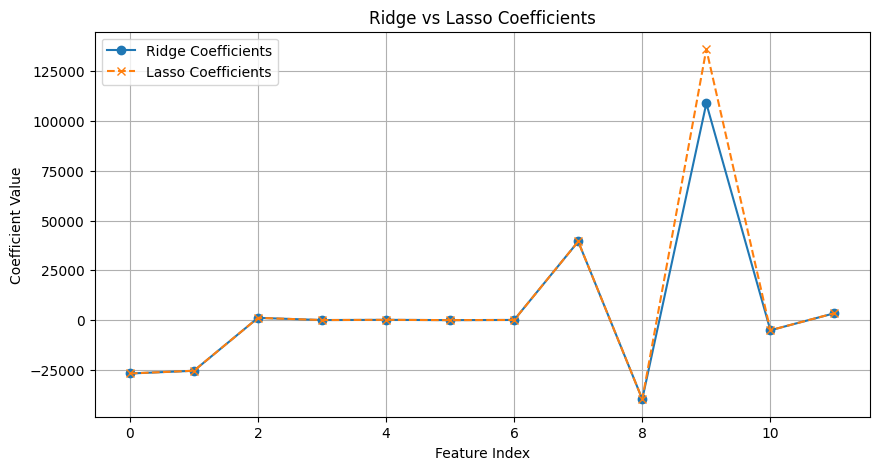

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(best_ridge.coef_, marker='o', linestyle='-', label="Ridge Coefficients")
plt.plot(best_lasso.coef_, marker='x', linestyle='--', label="Lasso Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Ridge vs Lasso Coefficients")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [ ]:
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (455, 30)
Test set shape: (114, 30)


In [ ]:
baseline_model = LogisticRegression(max_iter=10000)  # default solver is lbfgs, handles L2 by default
baseline_model.fit(X_train, y_train)

# Coefficients
baseline_coefficients = pd.DataFrame({
    "Feature": load_breast_cancer().feature_names,
    "Coefficient": baseline_model.coef_[0]
})

print("\nBaseline Model Coefficients:")
print(baseline_coefficients)

# Accuracy
train_acc_baseline = accuracy_score(y_train, baseline_model.predict(X_train))
test_acc_baseline = accuracy_score(y_test, baseline_model.predict(X_test))

print("\nBaseline Model Accuracy:")
print("Training Accuracy:", train_acc_baseline)
print("Test Accuracy:", test_acc_baseline)


Baseline Model Coefficients:
                    Feature  Coefficient
0               mean radius     1.027437
1              mean texture     0.221451
2            mean perimeter    -0.362135
3                 mean area     0.025467
4           mean smoothness    -0.156235
5          mean compactness    -0.237713
6            mean concavity    -0.532558
7       mean concave points    -0.283692
8             mean symmetry    -0.226682
9    mean fractal dimension    -0.036494
10             radius error    -0.097102
11            texture error     1.370567
12          perimeter error    -0.181409
13               area error    -0.087196
14         smoothness error    -0.022455
15        compactness error     0.047361
16          concavity error    -0.042948
17     concave points error    -0.032402
18           symmetry error    -0.034737
19  fractal dimension error     0.011605
20             worst radius     0.111653
21            worst texture    -0.508877
22          worst perimeter

In [50]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=10000),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters from GridSearchCV:")
print(grid_search.best_params_)

# Evaluate best model
best_model = grid_search.best_estimator_
train_acc_best = accuracy_score(y_train, best_model.predict(X_train))
test_acc_best = accuracy_score(y_test, best_model.predict(X_test))

print("\nBest Model Accuracy:")
print("Training Accuracy:", train_acc_best)
print("Test Accuracy:", test_acc_best)


Best Hyperparameters from GridSearchCV:
{'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}

Best Model Accuracy:
Training Accuracy: 0.989010989010989
Test Accuracy: 0.9824561403508771


In [ ]:
l1_model = LogisticRegression(
    penalty="l1",
    C=grid_search.best_params_["C"],
    solver="liblinear",
    max_iter=10000
)
l1_model.fit(X_train, y_train)

# L2 Regularization
l2_model = LogisticRegression(
    penalty="l2",
    C=grid_search.best_params_["C"],
    solver="liblinear",
    max_iter=10000
)
l2_model.fit(X_train, y_train)

# Compare Coefficients
coeff_df = pd.DataFrame({
    "Feature": load_breast_cancer().feature_names,
    "L1_Coeff": l1_model.coef_[0],
    "L2_Coeff": l2_model.coef_[0]
})
print("\nL1 vs L2 Coefficients:")
print(coeff_df)

# Accuracy comparison
print("\nRegularization Model Accuracy:")
print("L1 Training Accuracy:", accuracy_score(y_train, l1_model.predict(X_train)))
print("L1 Test Accuracy:", accuracy_score(y_test, l1_model.predict(X_test)))
print("L2 Training Accuracy:", accuracy_score(y_train, l2_model.predict(X_train)))
print("L2 Test Accuracy:", accuracy_score(y_test, l2_model.predict(X_test)))



L1 vs L2 Coefficients:
                    Feature    L1_Coeff  L2_Coeff
0               mean radius    0.718185  5.402727
1              mean texture   -0.108383  0.265737
2            mean perimeter    0.099770 -0.526512
3                 mean area   -0.002106 -0.020955
4           mean smoothness    0.000000 -2.299222
5          mean compactness   47.248483 -0.216942
6            mean concavity  -12.196125 -3.569802
7       mean concave points -135.959271 -5.011061
8             mean symmetry   19.775952 -2.264184
9    mean fractal dimension    0.000000  0.367627
10             radius error    0.000000 -0.580365
11            texture error    1.730874  3.841693
12          perimeter error   -0.000642 -0.638756
13               area error   -0.197580 -0.107143
14         smoothness error    0.000000 -0.405912
15        compactness error    0.000000  3.572370
16          concavity error   50.203558  4.365775
17     concave points error    0.000000 -0.266369
18           symmetry erro

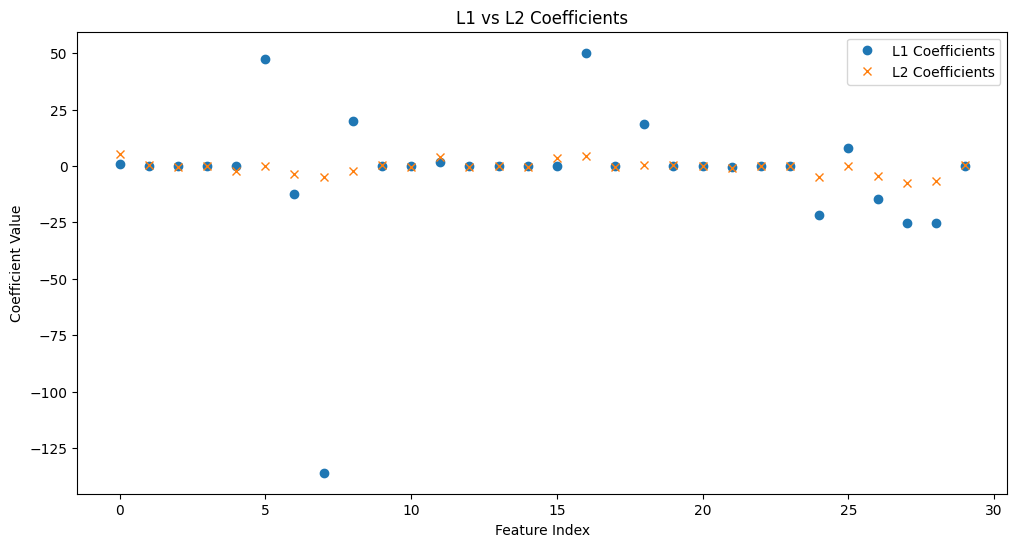

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(l1_model.coef_[0], "o", label="L1 Coefficients")
plt.plot(l2_model.coef_[0], "x", label="L2 Coefficients")
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("L1 vs L2 Coefficients")
plt.legend()
plt.show()